# CNN Assignment — Supervised Learning

Dataset: CIFAR-10  
Tasks: Data preprocessing, CNN architecture, regularization, optimizers, performance evaluation, and transfer learning.

## 0. Shared Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import display
import seaborn as sns
import time

np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']
NUM_CLASSES = 10
CHANNELS = 3

2026-04-30 01:11:46.688505: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777511506.891425      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777511506.951181      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777511507.468481      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777511507.468555      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777511507.468561      57 computation_placer.cc:177] computation placer alr

In [2]:
# Load CIFAR-10 and keep the required fixed split.
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]

x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]

x_test = x_test.astype('float32')

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 200s 1us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [3]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
                       epochs=20, batch_size=128, extra_callbacks=None, verbose=0):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()

    history = model.fit(
        x_tr,
        to_categorical(y_tr, NUM_CLASSES),
        validation_data=(x_v, to_categorical(y_v, NUM_CLASSES)),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=cb,
        verbose=verbose
    )

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, NUM_CLASSES), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed


def train_with_generator(model, generator, x_v, y_v, x_te, y_te,
                         epochs=40, extra_callbacks=None, verbose=0):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()

    history = model.fit(
        generator,
        validation_data=(x_v, to_categorical(y_v, NUM_CLASSES)),
        epochs=epochs,
        callbacks=cb,
        verbose=verbose
    )

    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, NUM_CLASSES), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed


def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        epochs_range = range(1, len(h.history[metric]) + 1)
        plt.plot(epochs_range, h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def final_train_acc(history):
    return history.history['accuracy'][-1]


def final_val_acc(history):
    return history.history['val_accuracy'][-1]


def final_train_loss(history):
    return history.history['loss'][-1]


def final_val_loss(history):
    return history.history['val_loss'][-1]


def loss_epoch_1(history):
    return history.history['loss'][0]


def stopped_epoch(history):
    return len(history.history['loss'])


def best_val_loss(history):
    return min(history.history['val_loss'])


def first_epoch_reaches(history, metric='val_accuracy', threshold=0.65):
    values = history.history[metric]
    for idx, value in enumerate(values, start=1):
        if value > threshold:
            return idx
    return None


def count_params(weights):
    return int(np.sum([np.prod(w.shape) for w in weights]))

In [4]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_filter_model(filters=(32, 32, 64, 64), input_shape=(32, 32, 3), optimizer=None):
    f1, f2, f3, f4 = filters

    model = models.Sequential([
        layers.Conv2D(f1, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(f2, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(f3, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    if optimizer is None:
        optimizer = keras.optimizers.Adam(learning_rate=0.001)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_medium_model(input_shape=(32, 32, 3), optimizer=None):
    return build_filter_model(filters=(32, 32, 64, 64), input_shape=input_shape, optimizer=optimizer)


def build_dropout_medium_model(dropout_rate=0.0):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
    ])

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2, 2)))

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))

    if dropout_rate > 0:
        model.add(layers.Dropout(dropout_rate))

    model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

## Task 1: Data Preprocessing Experiments

### 1A. Normalization Comparison

In [5]:
# Exp A: raw pixels
x_train_raw, x_val_raw, x_test_raw = x_train, x_val, x_test

# Exp B: min-max normalization
x_train_minmax = x_train / 255.0
x_val_minmax = x_val / 255.0
x_test_minmax = x_test / 255.0

# Exp C: per-channel standardization using training data only
channel_mean = np.mean(x_train, axis=(0, 1, 2), keepdims=True)
channel_std = np.std(x_train, axis=(0, 1, 2), keepdims=True)

x_train_standardized = (x_train - channel_mean) / (channel_std + 1e-7)
x_val_standardized = (x_val - channel_mean) / (channel_std + 1e-7)
x_test_standardized = (x_test - channel_mean) / (channel_std + 1e-7)

# Short aliases used in later tasks
x_train_std = x_train_standardized
x_val_std = x_val_standardized
x_test_std = x_test_standardized

preprocessing_experiments = {
    'None (0-255)': (x_train_raw, x_val_raw, x_test_raw),
    'Min-Max [0,1]': (x_train_minmax, x_val_minmax, x_test_minmax),
    'Standardized': (x_train_standardized, x_val_standardized, x_test_standardized)
}

histories_1a = {}
results_1a = []

for name, (x_tr, x_v, x_te) in preprocessing_experiments.items():
    print(f"\nRunning 1A: {name}")
    model = build_baseline_cnn()
    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_tr, y_train, x_v, y_val, x_te, y_test,
        epochs=20, batch_size=128
    )

    histories_1a[name] = history
    results_1a.append({
        'Preprocessing': name,
        'Train Acc': final_train_acc(history),
        'Val Acc': final_val_acc(history),
        'Test Acc': test_acc,
        'Loss @ Epoch 1': loss_epoch_1(history)
    })

results_1a_df = pd.DataFrame(results_1a)
display(results_1a_df)


Running 1A: None (0-255)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777511740.546562      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777511740.552820      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1777511745.053015     132 service.cc:152] XLA service 0x7c7a9402a960 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777511745.053062     132 servic

Test Acc: 0.5665 | Test Loss: 2.9500 | Time: 50.7s

Running 1A: Min-Max [0,1]
Test Acc: 0.6593 | Test Loss: 1.3474 | Time: 49.1s

Running 1A: Standardized
Test Acc: 0.6693 | Test Loss: 1.9955 | Time: 48.9s


,Preprocessing,Train Acc,Val Acc,Test Acc,Loss @ Epoch 1
0,None (0-255),0.908400,0.5561,0.5665,3.496673
1,"Min-Max [0,1]",0.889025,0.6674,0.6593,1.568635
2,Standardized,0.958775,0.6689,0.6693,1.454512


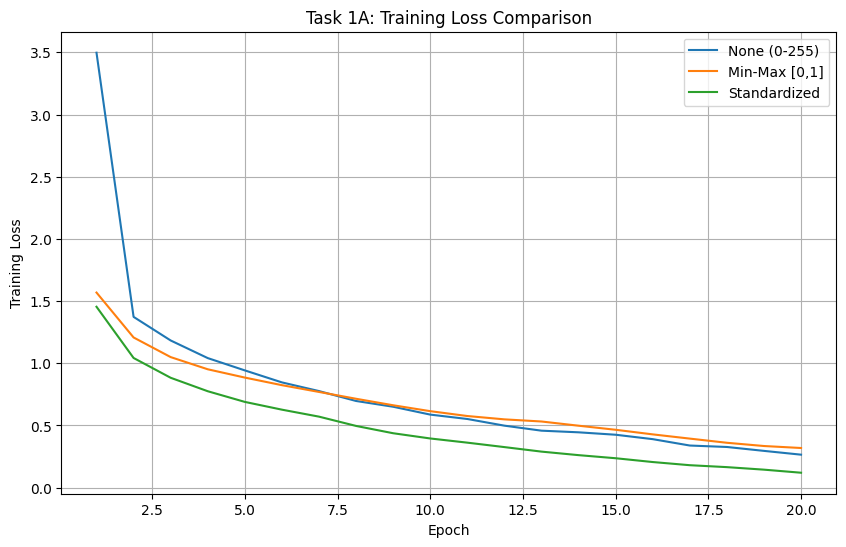

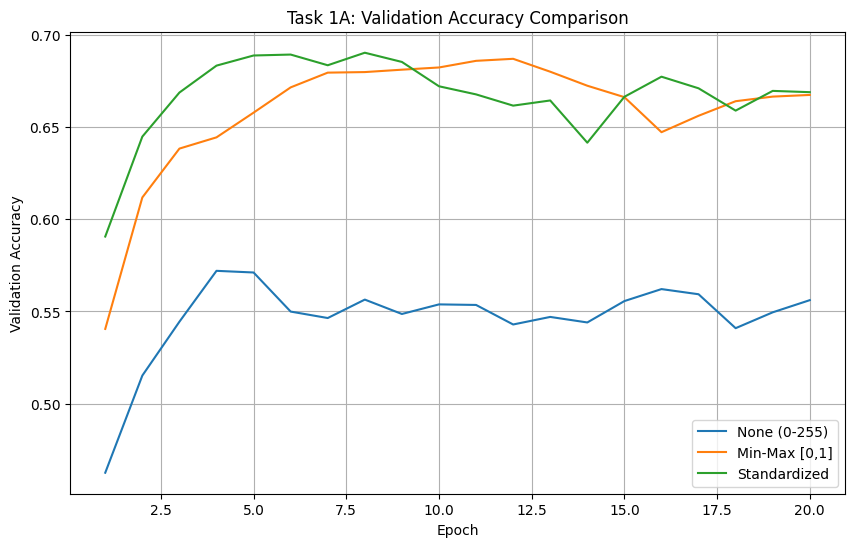

In [6]:
plot_curves(
    histories=list(histories_1a.values()),
    labels=list(histories_1a.keys()),
    metric='loss',
    title='Task 1A: Training Loss Comparison',
    ylabel='Training Loss'
)

plot_curves(
    histories=list(histories_1a.values()),
    labels=list(histories_1a.keys()),
    metric='val_accuracy',
    title='Task 1A: Validation Accuracy Comparison',
    ylabel='Validation Accuracy'
)

### 1B. Data Augmentation Comparison

In [7]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train_standardized)

print("\nRunning 1B: Without Augmentation")
model_no_aug = build_baseline_cnn()
history_no_aug, test_acc_no_aug, test_loss_no_aug, time_no_aug = train_and_evaluate(
    model_no_aug,
    x_train_standardized, y_train,
    x_val_standardized, y_val,
    x_test_standardized, y_test,
    epochs=40,
    batch_size=128
)

print("\nRunning 1B: With Augmentation")
model_aug = build_baseline_cnn()
aug_generator = datagen.flow(
    x_train_standardized,
    to_categorical(y_train, NUM_CLASSES),
    batch_size=128
)

history_aug, test_acc_aug, test_loss_aug, time_aug = train_with_generator(
    model_aug,
    aug_generator,
    x_val_standardized, y_val,
    x_test_standardized, y_test,
    epochs=40
)

gap_no_aug = final_train_acc(history_no_aug) - final_val_acc(history_no_aug)
gap_aug = final_train_acc(history_aug) - final_val_acc(history_aug)

results_1b_df = pd.DataFrame([
    {
        'Experiment': 'No Augmentation',
        'Train Acc @ Epoch 40': final_train_acc(history_no_aug),
        'Val Acc @ Epoch 40': final_val_acc(history_no_aug),
        'Test Acc': test_acc_no_aug,
        'Overfit Gap': gap_no_aug,
        'Time (s)': time_no_aug
    },
    {
        'Experiment': 'With Augmentation',
        'Train Acc @ Epoch 40': final_train_acc(history_aug),
        'Val Acc @ Epoch 40': final_val_acc(history_aug),
        'Test Acc': test_acc_aug,
        'Overfit Gap': gap_aug,
        'Time (s)': time_aug
    }
])

display(results_1b_df)

if abs(gap_aug) < abs(gap_no_aug):
    print("With augmentation overfits less based on the smaller train-validation gap.")
else:
    print("Without augmentation has the smaller train-validation gap in this run.")


Running 1B: Without Augmentation


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.6778 | Test Loss: 3.0014 | Time: 90.7s

Running 1B: With Augmentation


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Test Acc: 0.7852 | Test Loss: 0.6881 | Time: 942.4s


,Experiment,Train Acc @ Epoch 40,Val Acc @ Epoch 40,Test Acc,Overfit Gap,Time (s)
0,No Augmentation,0.99065,0.6835,0.6778,0.30715,90.713287
1,With Augmentation,0.81080,0.7885,0.7852,0.02230,942.405041


With augmentation overfits less based on the smaller train-validation gap.


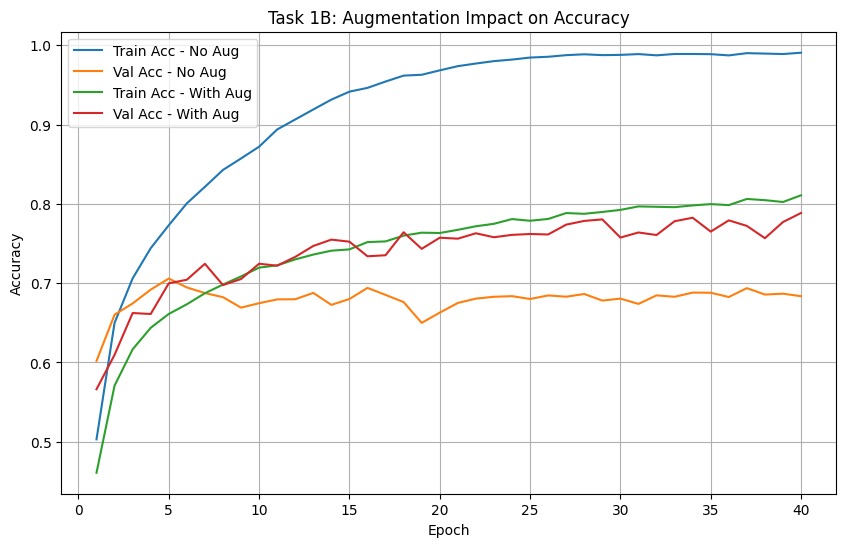

In [8]:
epochs_no_aug = range(1, len(history_no_aug.history['accuracy']) + 1)
epochs_aug = range(1, len(history_aug.history['accuracy']) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_no_aug, history_no_aug.history['accuracy'], label='Train Acc - No Aug')
plt.plot(epochs_no_aug, history_no_aug.history['val_accuracy'], label='Val Acc - No Aug')
plt.plot(epochs_aug, history_aug.history['accuracy'], label='Train Acc - With Aug')
plt.plot(epochs_aug, history_aug.history['val_accuracy'], label='Val Acc - With Aug')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Task 1B: Augmentation Impact on Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## Task 2: CNN Architecture Experiments

### 2A. Filter Count Comparison

In [9]:
filter_configs = {
    'Small': (8, 8, 16, 16),
    'Medium': (32, 32, 64, 64),
    'Large': (64, 64, 128, 128)
}

histories_2a = {}
results_2a = []

for name, filters in filter_configs.items():
    print(f"\nRunning 2A: {name} Model | filters={filters}")
    model = build_filter_model(filters=filters)
    model.summary()

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model,
        x_train_standardized, y_train,
        x_val_standardized, y_val,
        x_test_standardized, y_test,
        epochs=20,
        batch_size=128
    )

    histories_2a[name] = history
    results_2a.append({
        'Model': name,
        'Total Params': model.count_params(),
        'Train Acc': final_train_acc(history),
        'Val Acc': final_val_acc(history),
        'Test Acc': test_acc,
        'Time (s)': elapsed
    })

results_2a_df = pd.DataFrame(results_2a)
display(results_2a_df)


Running 2A: Small Model | filters=(8, 8, 16, 16)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,266 (1.03 MB)

...

 Total params: 2,360,138 (9.00 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7235 | Test Loss: 2.0963 | Time: 151.5s


,Model,Total Params,Train Acc,Val Acc,Test Acc,Time (s)
0,Small,269266,0.925525,0.6075,0.6070,45.314324
1,Medium,1116970,0.986525,0.7184,0.7150,84.130270
2,Large,2360138,0.984575,0.7365,0.7235,151.523230


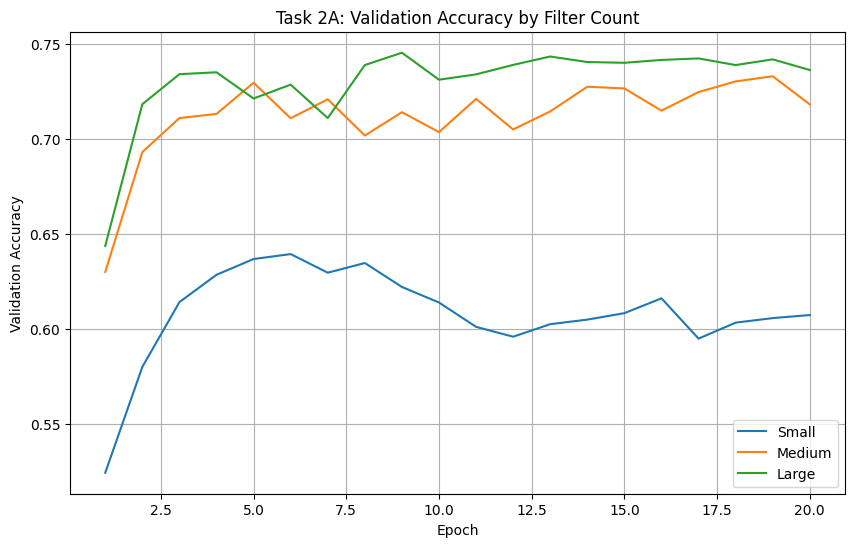

In [10]:
plot_curves(
    histories=list(histories_2a.values()),
    labels=list(histories_2a.keys()),
    metric='val_accuracy',
    title='Task 2A: Validation Accuracy by Filter Count',
    ylabel='Validation Accuracy'
)

### 2C. Network Depth Comparison

In [11]:
def build_shallow_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_medium_depth_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_deep_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [12]:
depth_builders = {
    'Shallow': build_shallow_model,
    'Medium Depth': build_medium_depth_model,
    'Deep': build_deep_model
}

histories_2c = {}
results_2c = []

for name, builder in depth_builders.items():
    print(f"\nRunning 2C: {name}")
    model = builder()
    model.summary()

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model,
        x_train_standardized, y_train,
        x_val_standardized, y_val,
        x_test_standardized, y_test,
        epochs=20,
        batch_size=128
    )

    histories_2c[name] = history
    results_2c.append({
        'Model': name,
        'Total Params': model.count_params(),
        'Train Acc': final_train_acc(history),
        'Val Acc': final_val_acc(history),
        'Test Acc': test_acc,
        'Time (s)': elapsed
    })

results_2c_df = pd.DataFrame(results_2c)
display(results_2c_df)


Running 2C: Shallow


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_24 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 16, 16, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 555,754 (2.12 MB)

...

 Total params: 76,650 (299.41 KB)

 Trainable params: 76,650 (299.41 KB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7178 | Test Loss: 0.9043 | Time: 79.1s


,Model,Total Params,Train Acc,Val Acc,Test Acc,Time (s)
0,Shallow,555754,0.980600,0.6926,0.6886,71.375727
1,Medium Depth,58154,0.791050,0.7482,0.7412,74.978562
2,Deep,76650,0.836325,0.7238,0.7178,79.109972


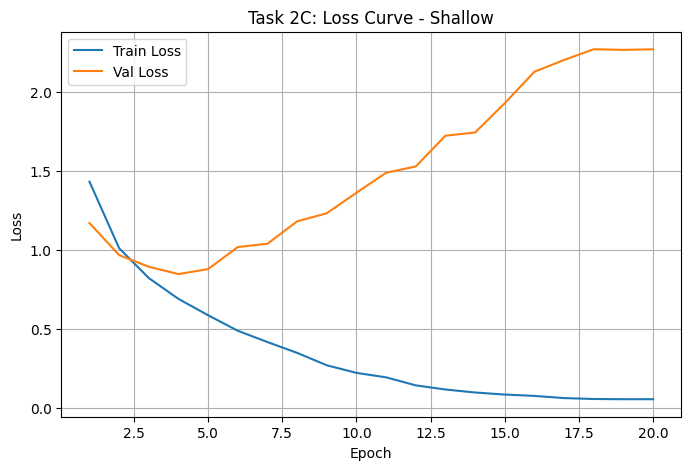

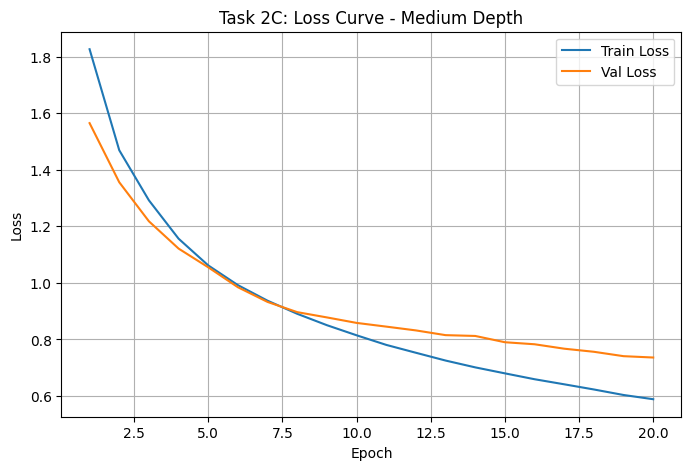

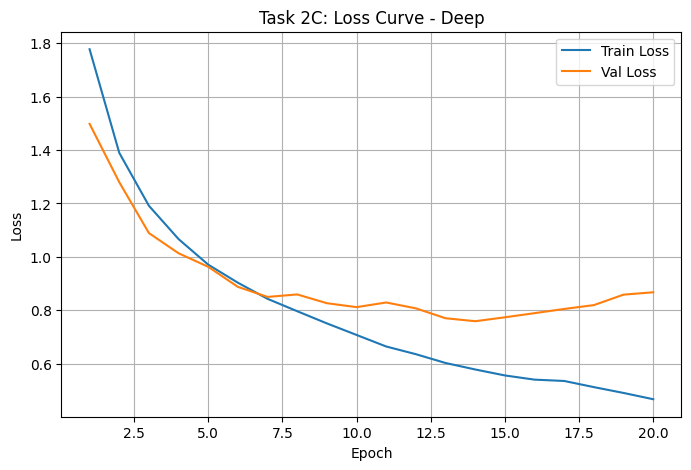

Best test accuracy in this run: Medium Depth.
The deepest model is not guaranteed to perform best. Extra depth can improve feature extraction, but it can also increase optimization difficulty and overfitting, especially on small 32x32 images.


In [13]:
for name, history in histories_2c.items():
    epochs_range = range(1, len(history.history['loss']) + 1)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs_range, history.history['loss'], label='Train Loss')
    plt.plot(epochs_range, history.history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Task 2C: Loss Curve - {name}')
    plt.legend()
    plt.grid(True)
    plt.show()

best_depth = results_2c_df.loc[results_2c_df['Test Acc'].idxmax(), 'Model']
print(f"Best test accuracy in this run: {best_depth}.")
print("The deepest model is not guaranteed to perform best. Extra depth can improve feature extraction, but it can also increase optimization difficulty and overfitting, especially on small 32x32 images.")

## Task 3: Regularization Experiments

### 3A. Dropout Rate Comparison

In [14]:
dropout_configs = {
    'D0': 0.0,
    'D1': 0.25,
    'D2': 0.5
}

histories_3a = {}
results_3a = []

for name, dropout_rate in dropout_configs.items():
    print(f"\nRunning 3A: {name} | dropout={dropout_rate}")
    model = build_dropout_medium_model(dropout_rate=dropout_rate)
    model.summary()

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model,
        x_train_standardized, y_train,
        x_val_standardized, y_val,
        x_test_standardized, y_test,
        epochs=30,
        batch_size=128
    )

    gap = final_train_acc(history) - final_val_acc(history)
    histories_3a[name] = history
    results_3a.append({
        'Model': name,
        'Train Acc': final_train_acc(history),
        'Val Acc': final_val_acc(history),
        'Test Acc': test_acc,
        'Overfit Gap': gap
    })

results_3a_df = pd.DataFrame(results_3a)
display(results_3a_df)

best_test_3a = results_3a_df.loc[results_3a_df['Test Acc'].idxmax(), 'Model']
smallest_gap_3a = results_3a_df.iloc[results_3a_df['Overfit Gap'].abs().idxmin()]['Model']

print(f"Best test accuracy: {best_test_3a}")
print(f"Smallest absolute overfit gap: {smallest_gap_3a}")


Running 3A: D0 | dropout=0.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_40 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,116,970 (4.26 MB)

...

 Trainable params: 1,116,970 (4.26 MB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7918 | Test Loss: 0.6115 | Time: 126.7s


,Model,Train Acc,Val Acc,Test Acc,Overfit Gap
0,D0,0.988675,0.7273,0.7192,0.261375
1,D1,0.932925,0.7754,0.7737,0.157525
2,D2,0.789450,0.7980,0.7918,-0.008550


Best test accuracy: D2
Smallest absolute overfit gap: D2


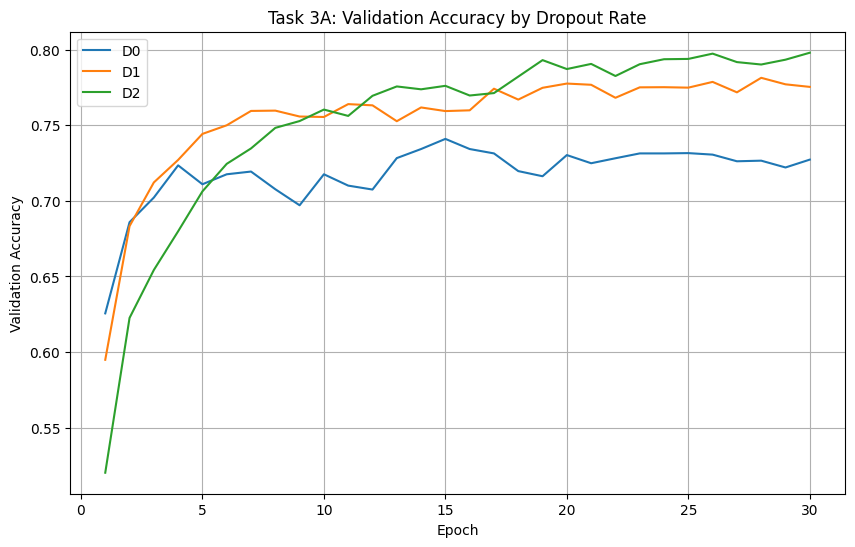

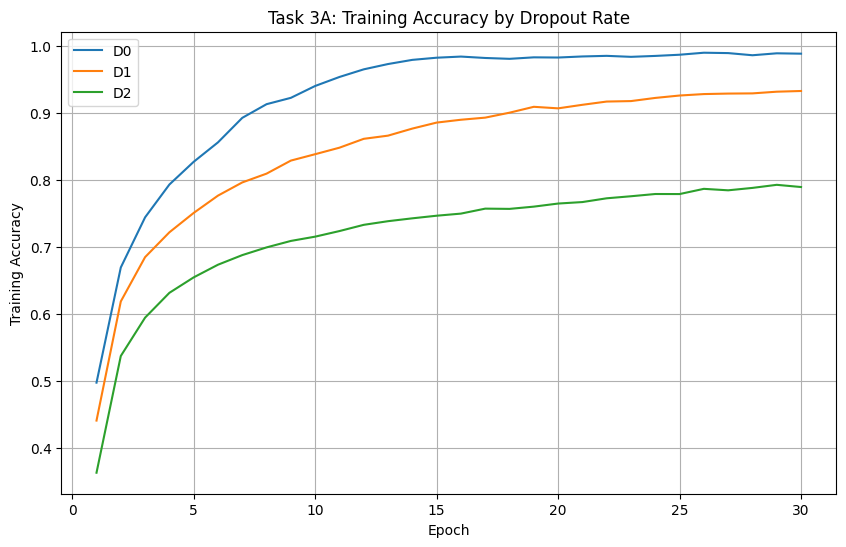

In [15]:
plot_curves(
    histories=list(histories_3a.values()),
    labels=list(histories_3a.keys()),
    metric='val_accuracy',
    title='Task 3A: Validation Accuracy by Dropout Rate',
    ylabel='Validation Accuracy'
)

plot_curves(
    histories=list(histories_3a.values()),
    labels=list(histories_3a.keys()),
    metric='accuracy',
    title='Task 3A: Training Accuracy by Dropout Rate',
    ylabel='Training Accuracy'
)

### 3B. Early Stopping Comparison

In [16]:
early_stopping_configs = {
    'ES0': None,
    'ES2': callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    'ES3': callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
}

histories_3b = {}
results_3b = {}

for name, es_callback in early_stopping_configs.items():
    print(f"\nRunning 3B: {name}")
    model = build_dropout_medium_model(dropout_rate=0.0)

    extra_callbacks = [es_callback] if es_callback is not None else None

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model,
        x_train_standardized, y_train,
        x_val_standardized, y_val,
        x_test_standardized, y_test,
        epochs=50,
        batch_size=128,
        extra_callbacks=extra_callbacks
    )

    histories_3b[name] = history
    results_3b[name] = {
        'Experiment': name,
        'Stopped at Epoch': stopped_epoch(history),
        'Best Val Loss': best_val_loss(history),
        'Test Acc': test_acc,
        'Time (s)': elapsed
    }

results_3b_df = pd.DataFrame(results_3b.values())
display(results_3b_df)


Running 3B: ES0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.7260 | Test Loss: 2.9567 | Time: 195.3s

Running 3B: ES2
Test Acc: 0.7193 | Test Loss: 0.8608 | Time: 42.0s

Running 3B: ES3
Test Acc: 0.7097 | Test Loss: 0.8591 | Time: 57.1s


,Experiment,Stopped at Epoch,Best Val Loss,Test Acc,Time (s)
0,ES0,50,0.818943,0.7260,195.322282
1,ES2,9,0.835124,0.7193,41.979116
2,ES3,13,0.833022,0.7097,57.080678


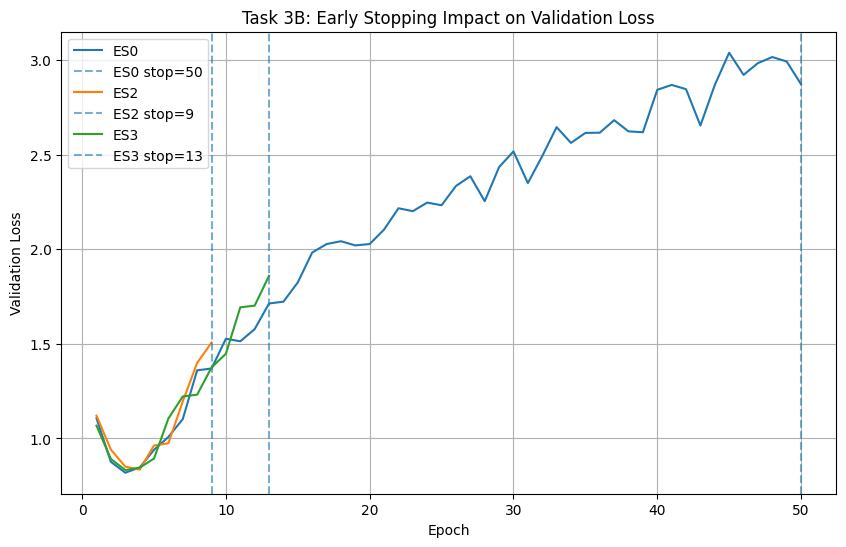

ES2 stopped at epoch 9; ES3 stopped at epoch 13.
Patience=5 is more aggressive because it stops after fewer epochs without validation loss improvement.
Patience=10 is more lenient because it allows more epochs before stopping, which can help if validation loss fluctuates, but may waste time if overfitting has already started.


In [17]:
plt.figure(figsize=(10, 6))

for name, history in histories_3b.items():
    epochs_range = range(1, len(history.history['val_loss']) + 1)
    plt.plot(epochs_range, history.history['val_loss'], label=name)
    plt.axvline(x=stopped_epoch(history), linestyle='--', alpha=0.6, label=f'{name} stop={stopped_epoch(history)}')

plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.title('Task 3B: Early Stopping Impact on Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

es2_epoch = results_3b['ES2']['Stopped at Epoch']
es3_epoch = results_3b['ES3']['Stopped at Epoch']

print(f"ES2 stopped at epoch {es2_epoch}; ES3 stopped at epoch {es3_epoch}.")
print("Patience=5 is more aggressive because it stops after fewer epochs without validation loss improvement.")
print("Patience=10 is more lenient because it allows more epochs before stopping, which can help if validation loss fluctuates, but may waste time if overfitting has already started.")

## Task 4: Optimizer Comparison

### 4A. Same Learning Rate — 5 Optimizers

In [18]:
optimizer_factories = {
    'SGD': lambda: keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': lambda: keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad': lambda: keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp': lambda: keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': lambda: keras.optimizers.Adam(learning_rate=0.001)
}

histories_4a = {}
results_4a = []

for name, opt_factory in optimizer_factories.items():
    print(f"\nRunning 4A: {name}")
    model = build_medium_model(optimizer=opt_factory())

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model,
        x_train_standardized, y_train,
        x_val_standardized, y_val,
        x_test_standardized, y_test,
        epochs=30,
        batch_size=128
    )

    histories_4a[name] = history
    results_4a.append({
        'Optimizer': name,
        'Train Loss (final)': final_train_loss(history),
        'Val Loss (final)': final_val_loss(history),
        'Test Acc': test_acc,
        'Time (s)': elapsed,
        'First Epoch val_acc > 0.65': first_epoch_reaches(history, threshold=0.65)
    })

results_4a_df = pd.DataFrame(results_4a)
display(results_4a_df)

reached = results_4a_df.dropna(subset=['First Epoch val_acc > 0.65'])
if len(reached) > 0:
    fastest_optimizer = reached.loc[reached['First Epoch val_acc > 0.65'].idxmin(), 'Optimizer']
    print(f"Fastest optimizer to reach val_acc > 0.65: {fastest_optimizer}")
else:
    print("No optimizer reached val_acc > 0.65 in this run.")


Running 4A: SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5038 | Test Loss: 1.3844 | Time: 115.0s

Running 4A: Momentum
Test Acc: 0.6624 | Test Loss: 1.3522 | Time: 118.6s

Running 4A: AdaGrad
Test Acc: 0.5664 | Test Loss: 1.2268 | Time: 117.3s

Running 4A: RMSProp
Test Acc: 0.7281 | Test Loss: 3.2576 | Time: 118.6s

Running 4A: Adam
Test Acc: 0.7120 | Test Loss: 2.4205 | Time: 121.3s


,Optimizer,Train Loss (final),Val Loss (final),Test Acc,Time (s),First Epoch val_acc > 0.65
0,SGD,1.329962,1.392382,0.5038,114.967135,NaN
1,Momentum,0.318825,1.320171,0.6624,118.579874,14.0
2,AdaGrad,1.120441,1.233786,0.5664,117.294304,NaN
3,RMSProp,0.037287,3.232386,0.7281,118.617293,3.0
4,Adam,0.038644,2.297165,0.7120,121.271836,2.0


Fastest optimizer to reach val_acc > 0.65: Adam


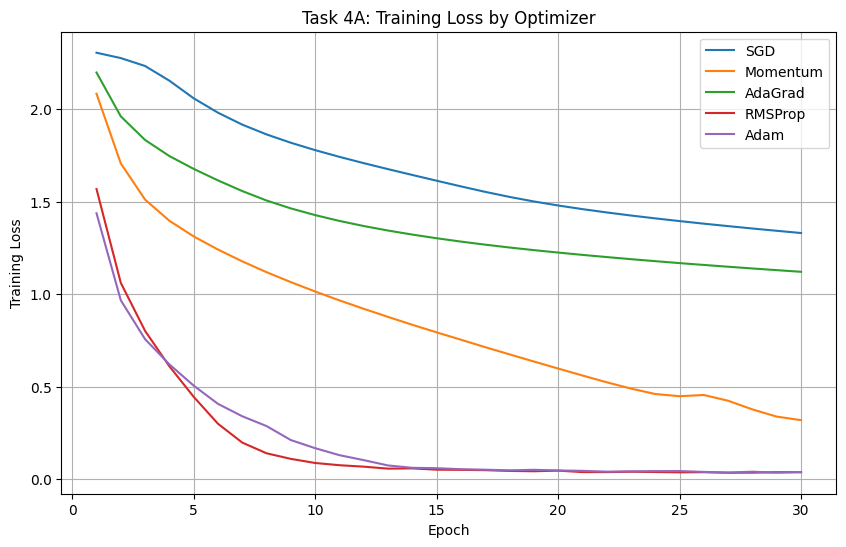

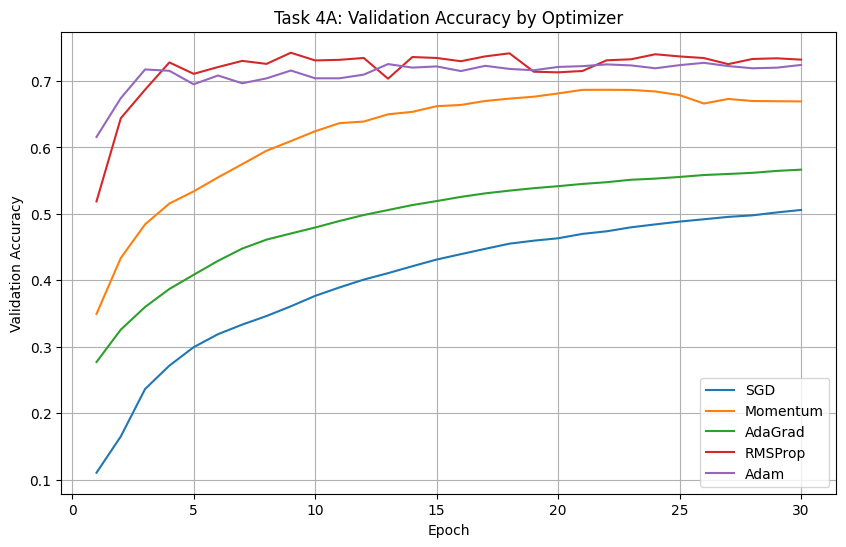

In [19]:
plot_curves(
    histories=list(histories_4a.values()),
    labels=list(histories_4a.keys()),
    metric='loss',
    title='Task 4A: Training Loss by Optimizer',
    ylabel='Training Loss'
)

plot_curves(
    histories=list(histories_4a.values()),
    labels=list(histories_4a.keys()),
    metric='val_accuracy',
    title='Task 4A: Validation Accuracy by Optimizer',
    ylabel='Validation Accuracy'
)

### 4B. Learning Rate Sensitivity — Adam

In [20]:
learning_rates = {
    '0.0001': 0.0001,
    '0.001': 0.001,
    '0.01': 0.01
}

histories_4b = {}
results_4b = []

for label, lr in learning_rates.items():
    print(f"\nRunning 4B: Adam lr={lr}")
    model = build_medium_model(optimizer=keras.optimizers.Adam(learning_rate=lr))

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model,
        x_train_standardized, y_train,
        x_val_standardized, y_val,
        x_test_standardized, y_test,
        epochs=30,
        batch_size=128
    )

    histories_4b[label] = history
    results_4b.append({
        'Learning Rate': label,
        'Train Loss (final)': final_train_loss(history),
        'Val Loss (final)': final_val_loss(history),
        'Test Acc': test_acc
    })

results_4b_df = pd.DataFrame(results_4b)
display(results_4b_df)

best_lr = results_4b_df.loc[results_4b_df['Test Acc'].idxmax(), 'Learning Rate']
print(f"Best learning rate by test accuracy in this run: {best_lr}")
print("A very small learning rate usually converges slowly; a large learning rate may become unstable or fail to settle near a good minimum.")


Running 4B: Adam lr=0.0001


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.6707 | Test Loss: 1.2933 | Time: 121.3s

Running 4B: Adam lr=0.001
Test Acc: 0.7164 | Test Loss: 2.6955 | Time: 119.4s

Running 4B: Adam lr=0.01
Test Acc: 0.1000 | Test Loss: 2.3032 | Time: 115.1s


,Learning Rate,Train Loss (final),Val Loss (final),Test Acc
0,0.0001,0.219738,1.30373,0.6707
1,0.001,0.038323,2.58797,0.7164
2,0.01,2.303370,2.30348,0.1000


Best learning rate by test accuracy in this run: 0.001
A very small learning rate usually converges slowly; a large learning rate may become unstable or fail to settle near a good minimum.


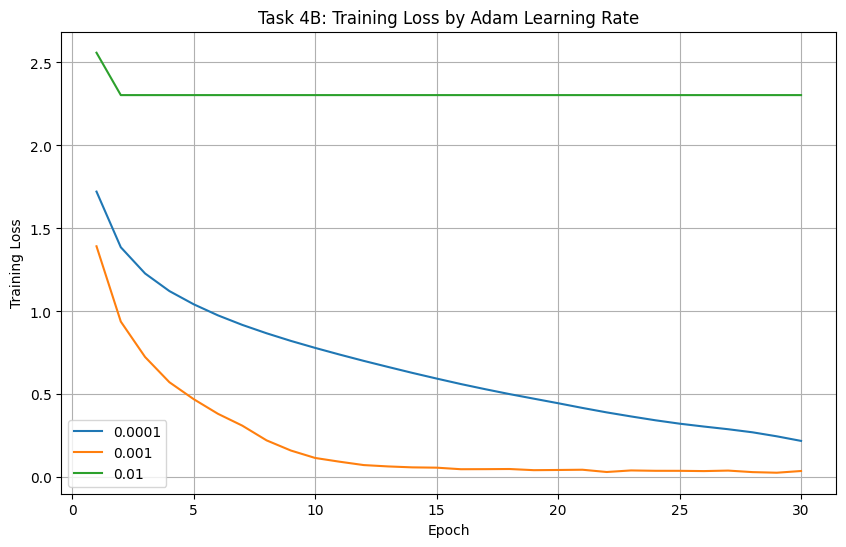

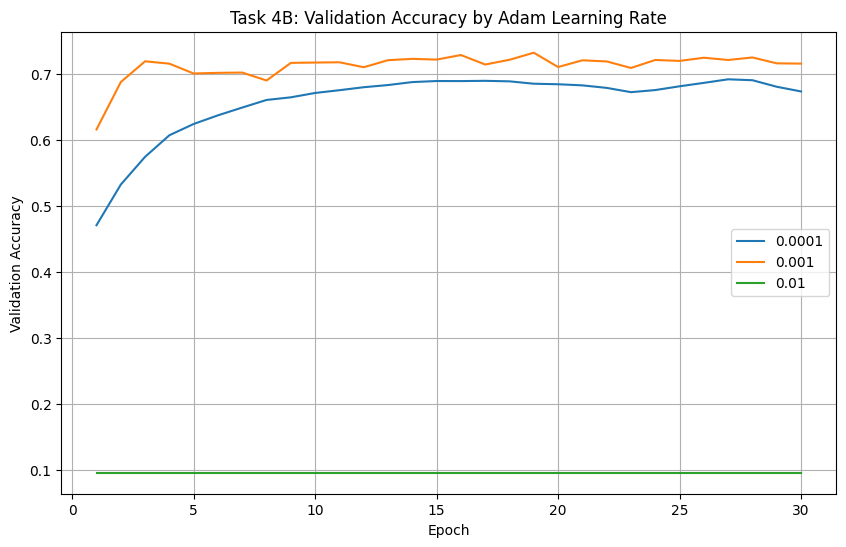

In [21]:
plot_curves(
    histories=list(histories_4b.values()),
    labels=list(histories_4b.keys()),
    metric='loss',
    title='Task 4B: Training Loss by Adam Learning Rate',
    ylabel='Training Loss'
)

plot_curves(
    histories=list(histories_4b.values()),
    labels=list(histories_4b.keys()),
    metric='val_accuracy',
    title='Task 4B: Validation Accuracy by Adam Learning Rate',
    ylabel='Validation Accuracy'
)

## Task 5: Performance Evaluation

### 5A. Best Model Selection & Evaluation

In [22]:
print("Chosen settings:")
print("- Preprocessing: per-channel standardization, because it gave normalized inputs while keeping channel statistics from the training set only.")
print("- Architecture: deeper CNN with 32/64/128 filters, because it can learn richer features than the baseline while still staying compact.")
print("- Dropout: 0.4 after pooling blocks and 0.5 before classification, because it reduces overfitting.")
print("- Optimizer: Adam with learning_rate=0.001, because it usually converges quickly and performed well in the optimizer experiments.")
print("- Batch size: 128, matching the assignment training configuration.")

def build_best_model():
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),

        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.5),
        layers.Dense(256, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

best_model = build_best_model()
best_model.summary()

best_es = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

best_generator = datagen.flow(
    x_train_standardized,
    to_categorical(y_train, NUM_CLASSES),
    batch_size=128
)

history_best, best_test_acc, best_test_loss, best_elapsed = train_with_generator(
    best_model,
    best_generator,
    x_val_standardized, y_val,
    x_test_standardized, y_test,
    epochs=50,
    extra_callbacks=[best_es]
)

print(f"Final Test Accuracy: {best_test_acc:.4f}")
print(f"Final Test Loss: {best_test_loss:.4f}")
print(f"Training Time: {best_elapsed:.1f}s")

Chosen settings:
- Preprocessing: per-channel standardization, because it gave normalized inputs while keeping channel statistics from the training set only.
- Architecture: deeper CNN with 32/64/128 filters, because it can learn richer features than the baseline while still staying compact.
- Dropout: 0.4 after pooling blocks and 0.5 before classification, because it reduces overfitting.
- Optimizer: Adam with learning_rate=0.001, because it usually converges quickly and performed well in the optimizer experiments.
- Batch size: 128, matching the assignment training configuration.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_96 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_97 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_51 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_98 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_99 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_52 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_100 (Conv2D)             │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_101 (Conv2D)             │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,602 (1.23 MB)

 Trainable params: 322,602 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Test Acc: 0.7978 | Test Loss: 0.5845 | Time: 1180.3s
Final Test Accuracy: 0.7978
Final Test Loss: 0.5845
Training Time: 1180.3s


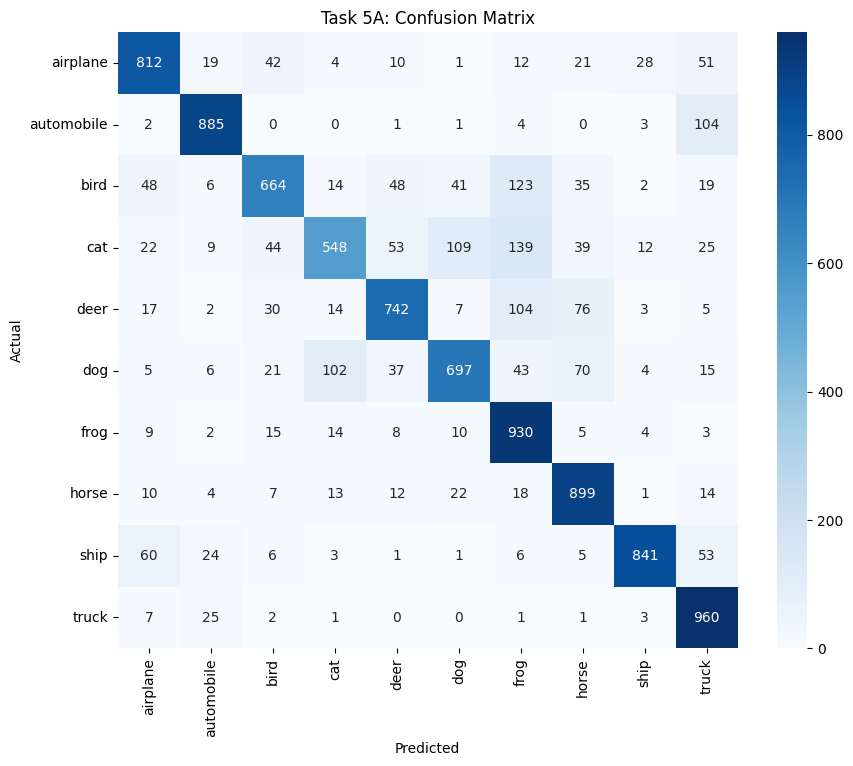

              precision    recall  f1-score   support

    airplane       0.82      0.81      0.82      1000
  automobile       0.90      0.89      0.89      1000
        bird       0.80      0.66      0.73      1000
         cat       0.77      0.55      0.64      1000
        deer       0.81      0.74      0.78      1000
         dog       0.78      0.70      0.74      1000
        frog       0.67      0.93      0.78      1000
       horse       0.78      0.90      0.84      1000
        ship       0.93      0.84      0.88      1000
       truck       0.77      0.96      0.85      1000

    accuracy                           0.80     10000
   macro avg       0.80      0.80      0.79     10000
weighted avg       0.80      0.80      0.79     10000



In [23]:
y_pred = np.argmax(best_model.predict(x_test_standardized, verbose=0), axis=1)
y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Task 5A: Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

### 5B. Error Analysis

Three worst-performing classes by recall:
cat: recall=0.5480
bird: recall=0.6640
dog: recall=0.6970
Total misclassified: 2022 / 10000


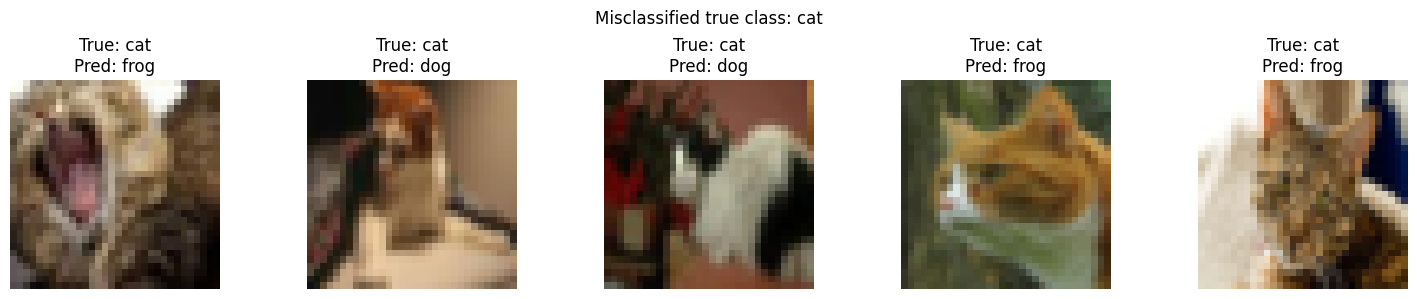

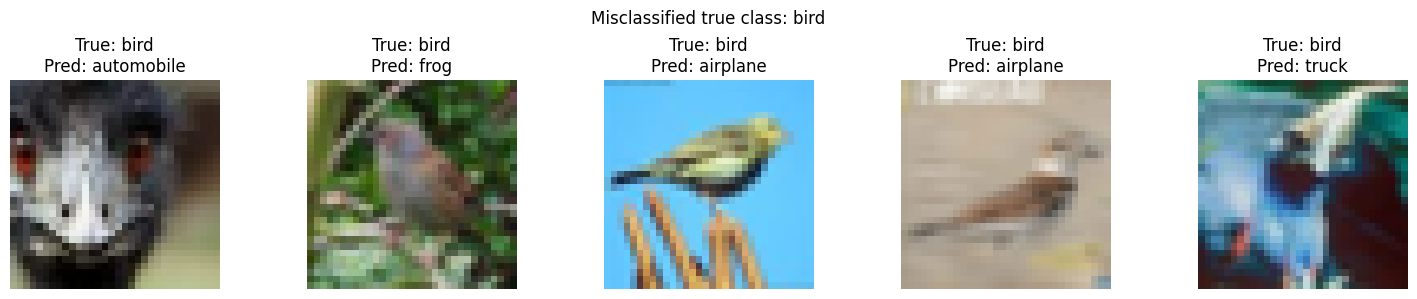

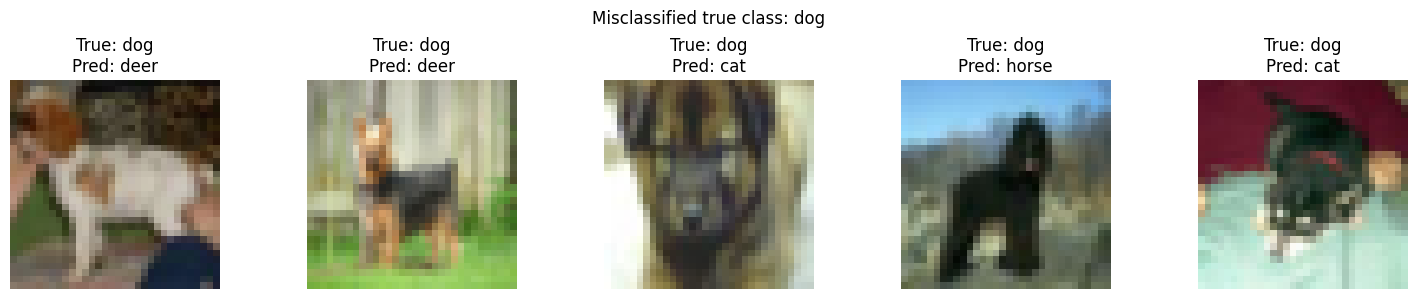

In [24]:
report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True)

class_recalls = []
for class_name in CLASS_NAMES:
    class_recalls.append((class_name, report_dict[class_name]['recall']))

worst_classes = sorted(class_recalls, key=lambda x: x[1])[:3]

print("Three worst-performing classes by recall:")
for class_name, recall in worst_classes:
    print(f"{class_name}: recall={recall:.4f}")

misclassified_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_true)}")


def show_indices(indices, title, n=5):
    indices = list(indices)[:n]
    if len(indices) == 0:
        print(f"No examples found for: {title}")
        return

    fig, axes = plt.subplots(1, len(indices), figsize=(3 * len(indices), 3))
    if len(indices) == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        ax.imshow(x_test[idx].astype('uint8'))
        ax.set_title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}")
        ax.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


for class_name, _ in worst_classes:
    class_id = CLASS_NAMES.index(class_name)
    idx = [i for i in misclassified_idx if y_true[i] == class_id]
    show_indices(idx, f"Misclassified true class: {class_name}", n=5)

Top 3 most confused class pairs:
cat <-> dog | total=211 | cat→dog=109, dog→cat=102
cat <-> frog | total=153 | cat→frog=139, frog→cat=14
bird <-> frog | total=138 | bird→frog=123, frog→bird=15


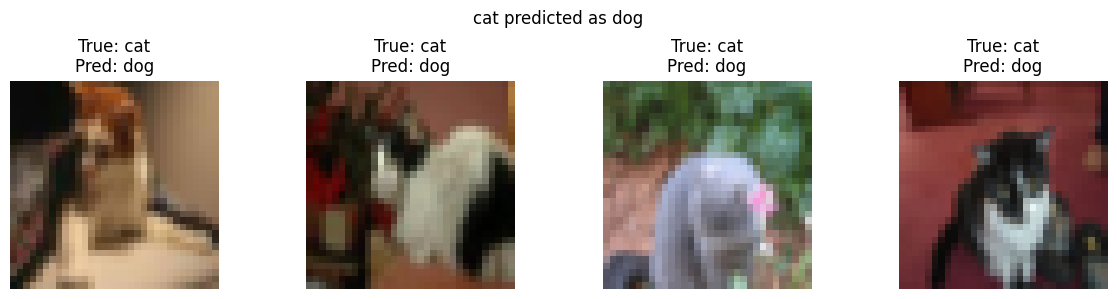

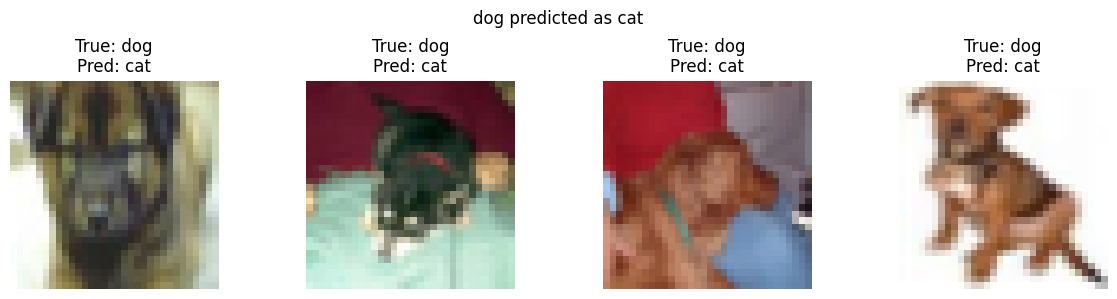

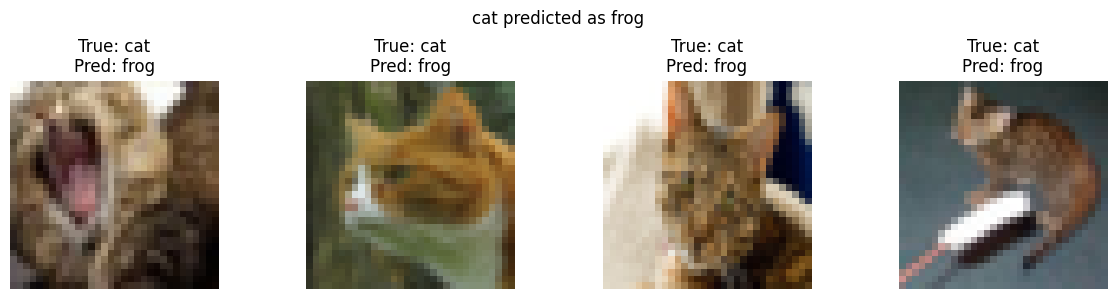

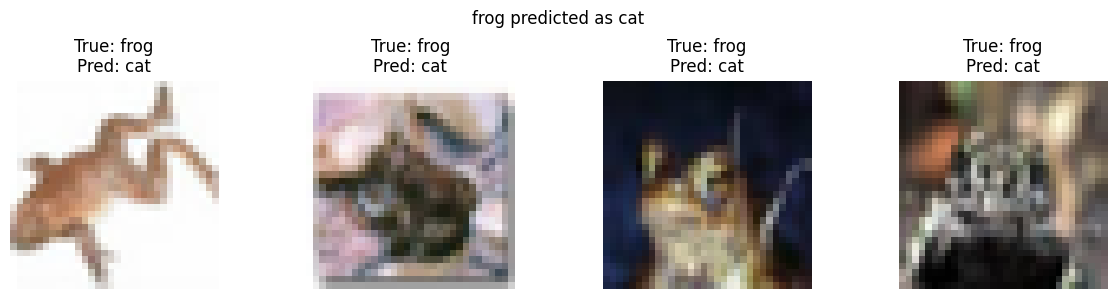

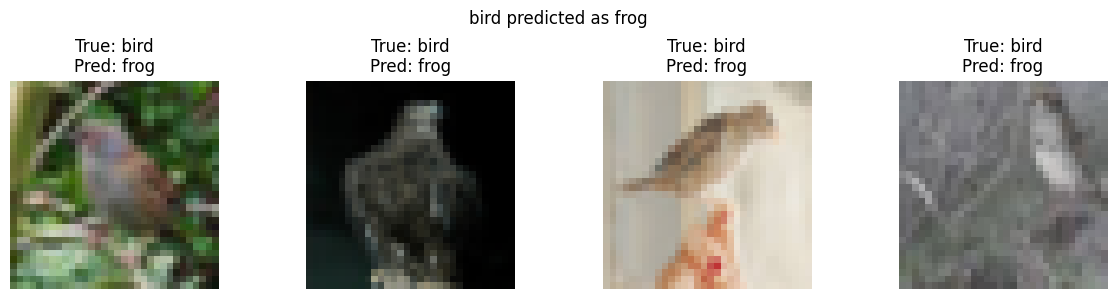

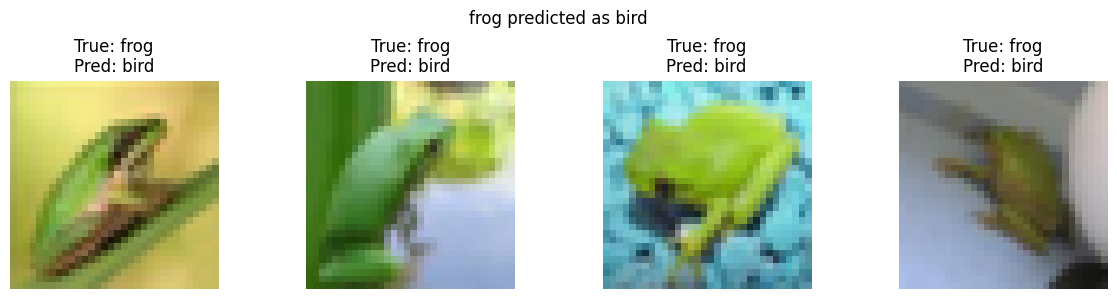

These classes are difficult because CIFAR-10 images are only 32x32, so fine details are limited. Visually similar animals or vehicles can share colors, textures, backgrounds, and object poses, which makes their learned feature maps harder to separate.


In [25]:
# Top confused undirected class pairs.
pair_scores = []
for i in range(NUM_CLASSES):
    for j in range(i + 1, NUM_CLASSES):
        score = cm[i, j] + cm[j, i]
        pair_scores.append((i, j, score, cm[i, j], cm[j, i]))

top_pairs = sorted(pair_scores, key=lambda x: x[2], reverse=True)[:3]

print("Top 3 most confused class pairs:")
for i, j, total, i_to_j, j_to_i in top_pairs:
    print(f"{CLASS_NAMES[i]} <-> {CLASS_NAMES[j]} | total={total} | {CLASS_NAMES[i]}→{CLASS_NAMES[j]}={i_to_j}, {CLASS_NAMES[j]}→{CLASS_NAMES[i]}={j_to_i}")

for i, j, total, i_to_j, j_to_i in top_pairs:
    idx_i_to_j = np.where((y_true == i) & (y_pred == j))[0]
    idx_j_to_i = np.where((y_true == j) & (y_pred == i))[0]

    show_indices(idx_i_to_j, f"{CLASS_NAMES[i]} predicted as {CLASS_NAMES[j]}", n=4)
    show_indices(idx_j_to_i, f"{CLASS_NAMES[j]} predicted as {CLASS_NAMES[i]}", n=4)

print("These classes are difficult because CIFAR-10 images are only 32x32, so fine details are limited. Visually similar animals or vehicles can share colors, textures, backgrounds, and object poses, which makes their learned feature maps harder to separate.")

## Task 6: Transfer Learning

### 6A. Feature Extraction vs Fine-Tuning vs From Scratch

In [26]:
IMG_SIZE = (48, 48)

x_train_resized = tf.image.resize(x_train_standardized, IMG_SIZE).numpy()
x_val_resized = tf.image.resize(x_val_standardized, IMG_SIZE).numpy()
x_test_resized = tf.image.resize(x_test_standardized, IMG_SIZE).numpy()

print(f"Resized train: {x_train_resized.shape}")
print(f"Resized val: {x_val_resized.shape}")
print(f"Resized test: {x_test_resized.shape}")

Resized train: (40000, 48, 48, 3)
Resized val: (10000, 48, 48, 3)
Resized test: (10000, 48, 48, 3)


In [27]:
def build_scratch_48_model():
    return build_medium_model(input_shape=(48, 48, 3), optimizer=keras.optimizers.Adam(learning_rate=0.001))


def build_vgg_feature_extraction_model():
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS)
    )
    base_model.trainable = False

    model = models.Sequential([
        layers.InputLayer(input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS)),
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


def build_vgg_finetune_model(learning_rate):
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS)
    )

    base_model.trainable = True

    for layer in base_model.layers[:-4]:
        layer.trainable = False

    model = models.Sequential([
        layers.InputLayer(input_shape=(IMG_SIZE[0], IMG_SIZE[1], CHANNELS)),
        base_model,
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [28]:
transfer_models = {
    'From Scratch': build_scratch_48_model,
    'Feature Extraction': build_vgg_feature_extraction_model,
    'Fine-Tune (lr=1e-5)': lambda: build_vgg_finetune_model(learning_rate=1e-5),
    'Fine-Tune (lr=1e-3)': lambda: build_vgg_finetune_model(learning_rate=1e-3)
}

histories_6 = {}
results_6 = {}
models_6 = {}

for name, builder in transfer_models.items():
    print(f"\nRunning Task 6: {name}")
    model = builder()

    if name in ['Feature Extraction', 'Fine-Tune (lr=1e-5)']:
        model.summary()

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model,
        x_train_resized, y_train,
        x_val_resized, y_val,
        x_test_resized, y_test,
        epochs=20,
        batch_size=128
    )

    histories_6[name] = history
    models_6[name] = model
    results_6[name] = {
        'Model': name,
        'Trainable Params': count_params(model.trainable_weights),
        'Non-Trainable Params': count_params(model.non_trainable_weights),
        'Test Acc': test_acc,
        'Time (s)': elapsed
    }

results_6_df = pd.DataFrame(results_6.values())
display(results_6_df)


Running Task 6: From Scratch


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.6663 | Test Loss: 2.7842 | Time: 155.1s

Running Task 6: Feature Extraction
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_27"

...

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Test Acc: 0.8236 | Test Loss: 0.5507 | Time: 475.3s

Running Task 6: Fine-Tune (lr=1e-3)
Test Acc: 0.1000 | Test Loss: 2.3026 | Time: 463.9s


,Model,Trainable Params,Non-Trainable Params,Test Acc,Time (s)
0,From Scratch,2427690,0,0.6663,155.126870
1,Feature Extraction,133898,14714688,0.6940,414.659385
2,Fine-Tune (lr=1e-5),7213322,7635264,0.8236,475.325956
3,Fine-Tune (lr=1e-3),7213322,7635264,0.1000,463.850670


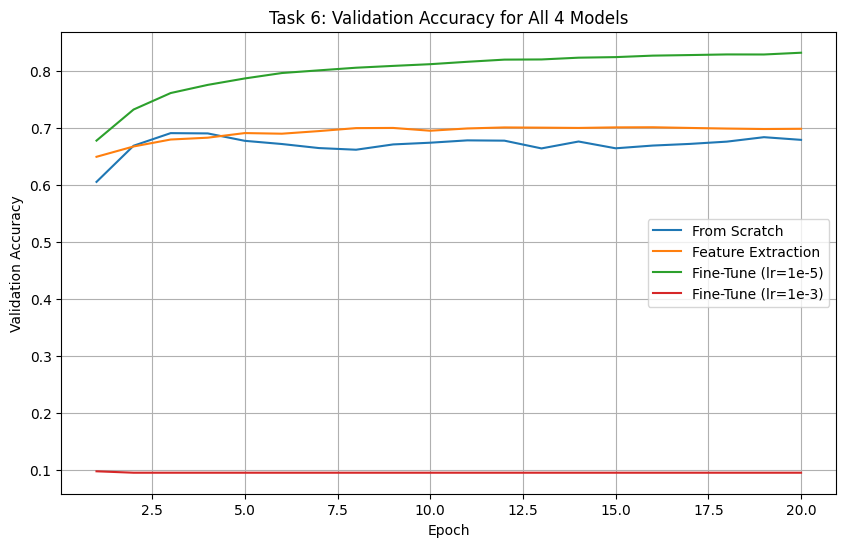

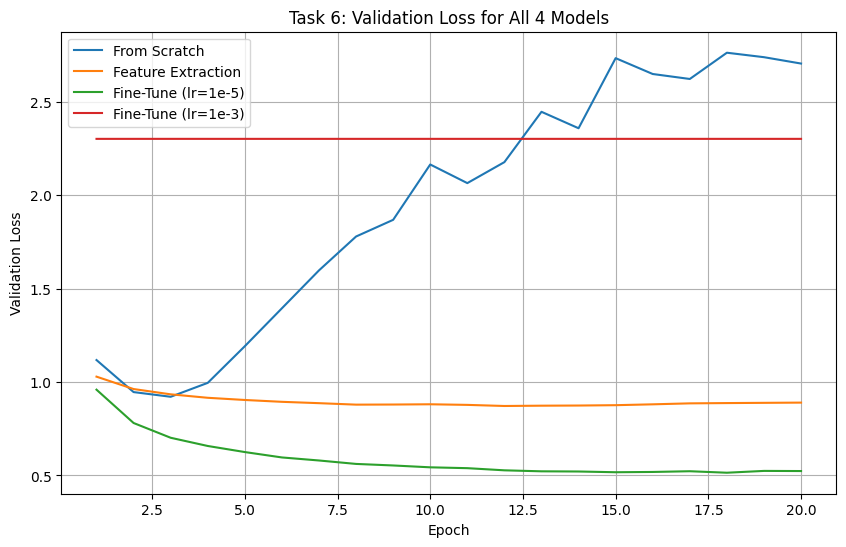

Best Task 6 model by test accuracy: Fine-Tune (lr=1e-5)
The higher fine-tuning learning rate can change pretrained weights too aggressively, which may damage useful ImageNet features. The smaller learning rate adjusts the high-level features more carefully.
Transfer learning can outperform training from scratch when pretrained features transfer well, but CIFAR-10 images are small and differ from ImageNet, so the result depends on preprocessing, image size, and fine-tuning stability.


In [29]:
plot_curves(
    histories=list(histories_6.values()),
    labels=list(histories_6.keys()),
    metric='val_accuracy',
    title='Task 6: Validation Accuracy for All 4 Models',
    ylabel='Validation Accuracy'
)

plot_curves(
    histories=list(histories_6.values()),
    labels=list(histories_6.keys()),
    metric='val_loss',
    title='Task 6: Validation Loss for All 4 Models',
    ylabel='Validation Loss'
)

best_transfer = results_6_df.loc[results_6_df['Test Acc'].idxmax(), 'Model']
print(f"Best Task 6 model by test accuracy: {best_transfer}")
print("The higher fine-tuning learning rate can change pretrained weights too aggressively, which may damage useful ImageNet features. The smaller learning rate adjusts the high-level features more carefully.")
print("Transfer learning can outperform training from scratch when pretrained features transfer well, but CIFAR-10 images are small and differ from ImageNet, so the result depends on preprocessing, image size, and fine-tuning stability.")

## Final Checklist

In [30]:
checklist = pd.DataFrame([
    ['1A', 'Normalization comparison', 3, 'Completed'],
    ['1B', 'Data augmentation comparison', 2, 'Completed'],
    ['2A', 'Filter count comparison', 3, 'Completed'],
    ['2C', 'Network depth comparison', 3, 'Completed'],
    ['3A', 'Dropout rate comparison', 3, 'Completed'],
    ['3B', 'Early stopping comparison', 3, 'Completed'],
    ['4A', 'Optimizer comparison', 5, 'Completed'],
    ['4B', 'Learning rate comparison', 3, 'Completed'],
    ['5A', 'Best model + confusion matrix', 1, 'Completed'],
    ['5B', 'Error analysis', '-', 'Completed'],
    ['6A', 'Transfer learning', 4, 'Completed']
], columns=['Task', 'Experiment', 'Models/Runs', 'Status'])

display(checklist)

,Task,Experiment,Models/Runs,Status
0,1A,Normalization comparison,3,Completed by code above
1,1B,Data augmentation comparison,2,Completed by code above
2,2A,Filter count comparison,3,Completed by code above
3,2C,Network depth comparison,3,Completed by code above
4,3A,Dropout rate comparison,3,Completed by code above
5,3B,Early stopping comparison,3,Completed by code above
6,4A,Optimizer comparison,5,Completed by code above
7,4B,Learning rate comparison,3,Completed by code above
8,5A,Best model + confusion matrix,1,Completed by code above
9,5B,Error analysis,-,Completed by code above
